In [1]:
!pip install prophet

In [2]:
import pandas as pd
import numpy as np

from prophet import Prophet

import matplotlib.pyplot as plt

%matplotlib inline

In [5]:
from google.colab import files
uploaded = files.upload()


Saving monthly_revenue.csv to monthly_revenue.csv


In [6]:
import pandas as pd

monthly_revenue = pd.read_csv("monthly_revenue.csv")
monthly_revenue.head()

,Month,Revenue
0,2010-12,552372.860
1,2011-01,473731.900
2,2011-02,435534.070
3,2011-03,578576.210
4,2011-04,425222.671


In [7]:
print("="*50)

print("Dataset Shape")
print(monthly_revenue.shape)

print("\nColumns")
print(monthly_revenue.columns)

print("="*50)

Dataset Shape
(13, 2)

Columns
Index(['Month', 'Revenue'], dtype='object')


In [8]:
prophet_df = monthly_revenue.copy()

prophet_df.columns = [
    "ds",
    "y"
]

prophet_df["ds"] = pd.to_datetime(
    prophet_df["ds"]
)

prophet_df.head()

,ds,y
0,2010-12-01,552372.860
1,2011-01-01,473731.900
2,2011-02-01,435534.070
3,2011-03-01,578576.210
4,2011-04-01,425222.671


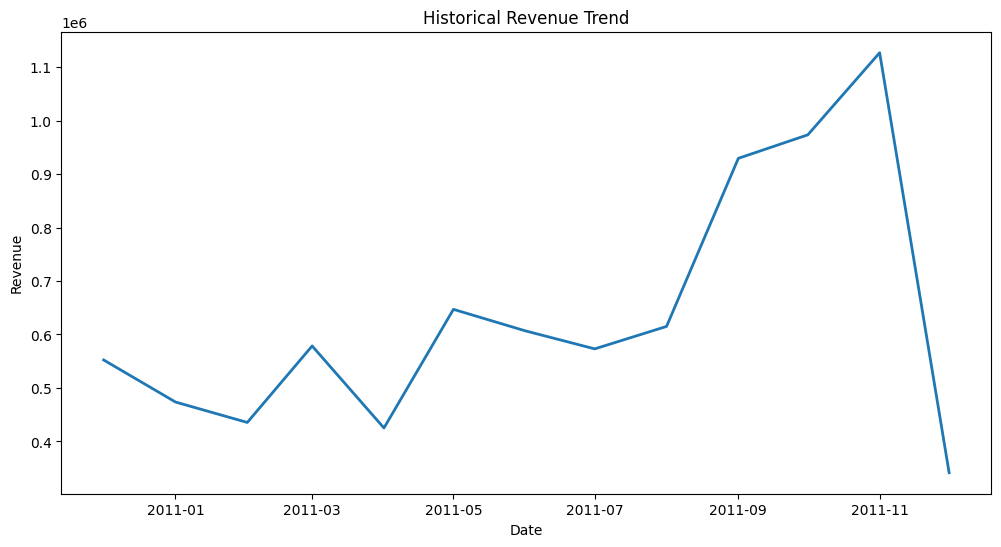

In [9]:
plt.figure(figsize=(12,6))

plt.plot(
    prophet_df["ds"],
    prophet_df["y"],
    linewidth=2
)

plt.title(
    "Historical Revenue Trend"
)

plt.xlabel("Date")
plt.ylabel("Revenue")

plt.show()

In [10]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(
    prophet_df
)

INFO:prophet:n_changepoints greater than number of observations. Using 9.


In [11]:
future = model.make_future_dataframe(
    periods=12,
    freq="M"
)

future.tail()

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds
20,2012-07-31
21,2012-08-31
22,2012-09-30
23,2012-10-31
24,2012-11-30


In [12]:
forecast = model.predict(
    future
)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2010-12-01,9.008834e+05,552372.976457,552372.976478,9.008834e+05,9.008834e+05,-348510.432308,-348510.432308,-348510.432308,-348510.432308,-348510.432308,-348510.432308,0.0,0.0,0.0,552372.976467
1,2011-01-01,9.399098e+05,473732.021975,473732.021997,9.399098e+05,9.399098e+05,-466177.818673,-466177.818673,-466177.818673,-466177.818673,-466177.818673,-466177.818673,0.0,0.0,0.0,473732.021986
2,2011-02-01,9.789363e+05,435533.960179,435533.960201,9.789363e+05,9.789363e+05,-543402.312345,-543402.312345,-543402.312345,-543402.312345,-543402.312345,-543402.312345,0.0,0.0,0.0,435533.960189
3,2011-03-01,1.020600e+06,578576.057588,578576.057610,1.020600e+06,1.020600e+06,-442023.935409,-442023.935409,-442023.935409,-442023.935409,-442023.935409,-442023.935409,0.0,0.0,0.0,578576.057599
4,2011-04-01,1.066728e+06,425222.745906,425222.745926,1.066728e+06,1.066728e+06,-641504.944082,-641504.944082,-641504.944082,-641504.944082,-641504.944082,-641504.944082,0.0,0.0,0.0,425222.745916


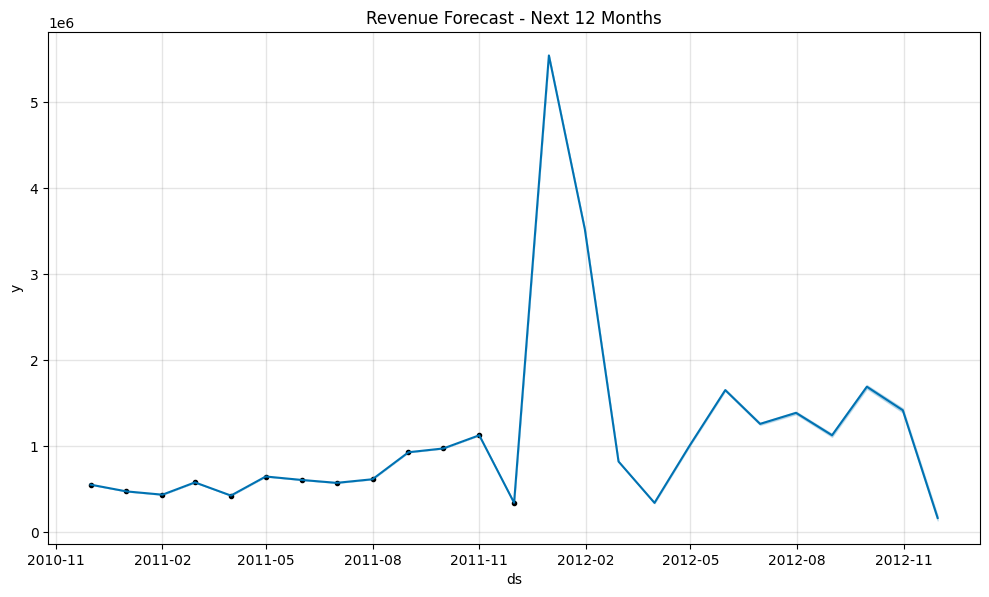

In [13]:
fig = model.plot(
    forecast
)

plt.title(
    "Revenue Forecast - Next 12 Months"
)

plt.show()

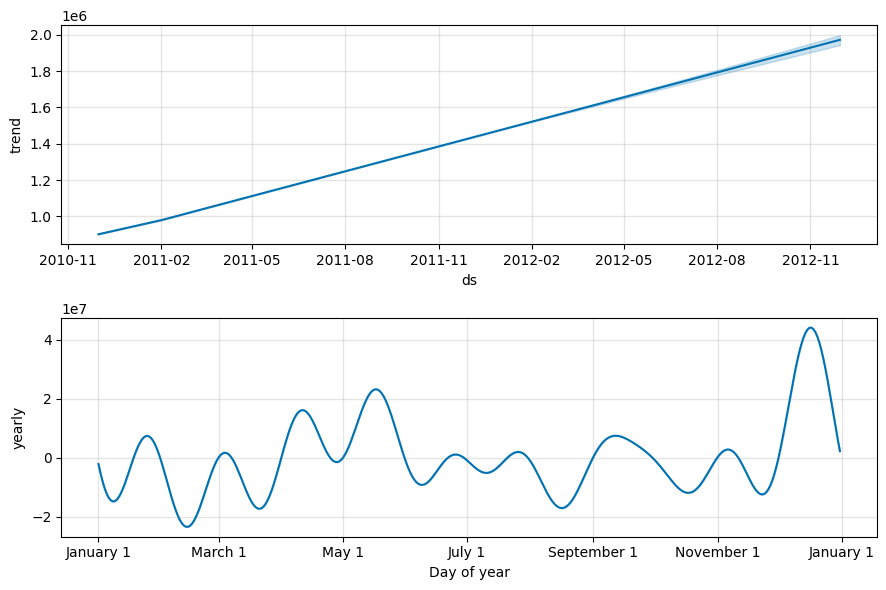

In [14]:
model.plot_components(
    forecast
)

plt.show()

In [16]:
future_forecast = forecast[
    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
].tail(12)

future_forecast

,ds,yhat,yhat_lower,yhat_upper
13,2011-12-31,5.545870e+06,5.545353e+06,5.546340e+06
14,2012-01-31,3.522439e+06,3.520747e+06,3.524022e+06
15,2012-02-29,8.217378e+05,8.185414e+05,8.248565e+05
16,2012-03-31,3.403932e+05,3.352363e+05,3.453067e+05
17,2012-04-30,1.000654e+06,9.934147e+05,1.007640e+06
18,2012-05-31,1.652497e+06,1.642996e+06,1.661634e+06
19,2012-06-30,1.259339e+06,1.247128e+06,1.270769e+06
20,2012-07-31,1.387662e+06,1.372272e+06,1.401852e+06
21,2012-08-31,1.126970e+06,1.108108e+06,1.143807e+06
22,2012-09-30,1.691527e+06,1.669322e+06,1.710941e+06


In [17]:
print(
    "Predicted Revenue For Next 12 Months"
)

future_forecast


Predicted Revenue For Next 12 Months


,ds,yhat,yhat_lower,yhat_upper
13,2011-12-31,5.545870e+06,5.545353e+06,5.546340e+06
14,2012-01-31,3.522439e+06,3.520747e+06,3.524022e+06
15,2012-02-29,8.217378e+05,8.185414e+05,8.248565e+05
16,2012-03-31,3.403932e+05,3.352363e+05,3.453067e+05
17,2012-04-30,1.000654e+06,9.934147e+05,1.007640e+06
18,2012-05-31,1.652497e+06,1.642996e+06,1.661634e+06
19,2012-06-30,1.259339e+06,1.247128e+06,1.270769e+06
20,2012-07-31,1.387662e+06,1.372272e+06,1.401852e+06
21,2012-08-31,1.126970e+06,1.108108e+06,1.143807e+06
22,2012-09-30,1.691527e+06,1.669322e+06,1.710941e+06


In [18]:
forecast.to_csv(
    "revenue_forecast.csv",
    index=False
)

print(
    "Revenue Forecast Saved Successfully!"
)

Revenue Forecast Saved Successfully!


In [19]:
from google.colab import files

files.download(
    "revenue_forecast.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>